
<br>

*Elaborado por Daniel Salmoran* <br> *Economista*

<br>



# 3. Monitor de las empresas que componen el índice S&P500.

## En este apartado se presenta una forma de analizar y graficar los datos de las empresas que componen el [índice S&P500](https://finance.yahoo.com/quote/%5EGSPC/), para después filtrar aquellas empresas con los mejores y peores desempeños en un periodo determinado.

## Al final de este apartado se utiliza la librería **[plotly](https://plotly.com/python/)** para realizar una gráfica interactiva que permite visualizar los datos de manera dinámica.

<br>

---

<br>

Para instalar/actualizar las librerías se puede usar:


In [3]:
#!pip install yfinance
#!pip install plotly

#!pip install --upgrade yfinance
#!pip install --upgrade plotly

<br>

Importamos las librerías con nombres abreviados:

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf

import plotly.graph_objects as go

<br>

A diferencia de las otras secciones donde declararamos los tickers a analizar, en este caso vamos a importar los símbolos desde una [tabla de internet](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies). Para conseguir esto, vamos a usar **[pandas.read_html](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_html.html)** para obtener los ticker:



In [7]:
#NOTA: Se actualiza la forma de obtener los datos de la tabla de Wikipedia agregando las librerias bs4, io y requests:

In [8]:
#Para instalar/actualizar las librerías se puede usar la siguientes lineas de código:
#!pip install bs4
#!pip install --upgrade bs4

In [9]:
#Las librerías que se importan son
import requests
from bs4 import BeautifulSoup
from io import StringIO

In [10]:
#definimos el url que muestra la lista de empresas que conforman el S&P500 y el header de la petición
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

#hacemos la solicitud
respuesta = requests.get(url, headers=headers)

#guardamos la repuesta como un objeto de bs4
soup = BeautifulSoup(respuesta.text, "html.parser")

#pasamos el objeto de bs4 a texto html
html_io = StringIO(str(soup))

#pasamos el texto html a un pd.DataFrame
tablas = pd.read_html(html_io)

#seleccionamos la tabla que contiene la informacion que necesitamos
tabla_con_simbolos = tablas[0]

#cambiamos dos simbolos 
tabla_con_simbolos["Symbol"]= tabla_con_simbolos["Symbol"].replace({"BRK.B": "BRK-B", "BF.B": "BF-B"});

#resultado
tabla_con_simbolos


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


<br>

De la anterior tabla seleccionamos la primera columna, la cual contiene la lista de símbolos con los tickers de las empresas:

In [12]:
lista_tickers= tabla_con_simbolos['Symbol']
lista_tickers

0       MMM
1       AOS
2       ABT
3      ABBV
4       ACN
       ... 
498     XYL
499     YUM
500    ZBRA
501     ZBH
502     ZTS
Name: Symbol, Length: 503, dtype: object

<br>

Realizamos una prueba rápida para confirmar que todos los tickers de la lista son válidos:

In [14]:
#declaramos una lista vacia para almacenar los tickers
tickers_validos= []
tickers_invalidos= []

#itineramos sobre cada elemento en la lista de empresas
for ticker in lista_tickers:      #PRECAUCION: debido a la cantidad de elementos en la lista, es probable que sea tardado ejecutar esta operacion
  data = yf.Ticker(ticker).info     #obtenemos la info del ticker

  if 'regularMarketPrice' in data:      #si existe este parametro en la info, es un ticker valido
    tickers_validos.append(ticker)
  else:                                 #si no existe, es un ticker invalido
    tickers_invalidos.append(ticker)

#resultados
print(f'tickers validos: {tickers_validos}')
print(f'tickers invalidos: {tickers_invalidos}')

tickers validos: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR',

<br>

Como se puede observar, existen dos tickers inválidos en la lista. Esto no significa que estén mal, sino que no son reconocidos dentro de Yahoo Finance. Si revisamos su página, notamos que los tickers no están separados por un punto ("."), sino por un [guión](https://finance.yahoo.com/quote/BRK-B/) ("-"). Realizamos la corrección pertinente:

In [16]:
#usamos el metodo "replace" de pandas
ticker_list = lista_tickers.replace({'BRK.B': 'BRK-B', 'BF.B': 'BF-B'})
ticker_list

0       MMM
1       AOS
2       ABT
3      ABBV
4       ACN
       ... 
498     XYL
499     YUM
500    ZBRA
501     ZBH
502     ZTS
Name: Symbol, Length: 503, dtype: object

<br>

Ahora que tenemos la lista de tickers, realizamos la consulta de los precios de cierre de los 503 símbolos que conforman el índice S&P500.

<br>

**NOTA: Debido al volumen de información con la que se está trabajando, es probable que sea tardado ejecutar esta operación. Es por esto que el procedimiento para crear la tabla de datos es distinto al utilizado en los otros apartados.**


In [18]:
#declaramos la lista que va a almacenar los datos de cada ticker
datos_diarios= []

#declaramos el DataFrame en el que vamos a juntar todos los datos
data= pd.DataFrame()

#obtenemos el precio de cada elemento de la lista con ayuda de yfinance y guardamos los datos
for simbolo in ticker_list:
    rawdata= yf.Ticker(simbolo).history(period= '1y')
    rawdata.rename(columns={"Close": simbolo}, inplace=True)      #Los datos de "Close" son los datos de cierre ajustados
    datos_diarios.append(rawdata[simbolo])

#concatenamos las listas de datos en el DataFrame
data = pd.concat(datos_diarios, axis=1)

#removemos el componente time-zone de la fecha que entrega yfinance
data.index = data.index.tz_localize(None)

#declaramos el formato de fecha en los datos de la primera columna
data.index = pd.to_datetime(data.index, format= '%Y-%m-%d %H:%M:%S')

#cambiamos el nombre del indice, antes: Date, ahora: Fecha
data.index.name = 'Fecha'

#resultado
data

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Fecha,,,,,,,,,,,,,,,,,,,,,
2024-10-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-10-18,132.501083,77.233040,117.169830,182.479492,371.555206,494.899994,155.970001,16.493517,112.116600,137.712967,...,50.589245,286.781494,244.479996,98.421883,62.010391,132.737625,131.705521,375.450012,105.312920,190.956848
2024-10-21,132.206940,77.085930,114.814453,180.237854,370.736938,497.709991,157.899994,16.248049,110.403030,135.659592,...,50.241421,287.246246,243.750000,97.362831,61.390965,130.958832,131.440674,372.589996,104.213326,187.172867
2024-10-22,129.157654,76.703445,113.960640,182.382858,366.556610,493.109985,154.089996,16.049788,109.825310,132.386185,...,50.531281,288.472351,246.759995,98.382286,61.632927,129.822372,130.812897,372.000000,103.282150,187.232162
2024-10-23,125.412270,75.810974,114.834084,181.532593,365.412964,485.029999,152.910004,16.125317,109.805725,131.959610,...,50.482964,288.650360,242.039993,96.679901,62.252354,130.168259,131.460297,368.089996,103.718018,186.718414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-13,151.100006,67.680000,130.798370,228.651627,243.559998,339.320007,216.419998,14.440000,110.260002,138.229996,...,62.680000,336.619995,236.600006,112.519997,80.160004,146.000000,140.470001,281.959991,95.089996,142.259995
2025-10-14,152.529999,68.820000,132.680008,227.490005,244.199997,335.940002,218.089996,14.390000,111.510002,138.039993,...,62.360001,343.309998,237.179993,116.110001,80.849998,146.570007,143.979996,288.989990,98.370003,143.460007
2025-10-15,153.470001,69.209999,129.449997,226.220001,239.710007,330.630005,238.600006,14.750000,109.809998,139.649994,...,63.779999,339.420013,234.759995,118.070000,81.800003,145.770004,144.509995,293.350006,99.379997,142.119995


<br>

Si a partir de este punto se prefiere continuar trabajando desde Excel, la línea de código para descargar el pd.DataFrame es:

In [20]:
data.to_excel('precios_de_cierre.xlsx')

ModuleNotFoundError: No module named 'openpyxl'

<br>

Obtenemos los rendimientos diarios:

In [ ]:
#hay dos opciones
#rendimiento aritmético:
rendimientos = round(((data/data.shift(1))-1), 4)

#rendimiento logarítmico:
rendimientos= round(np.log(data/data.shift(1)), 4)


#sustituimos los valores NaN por ceros para hacer coincidir el punto de partida en la gráfica
rendimientos.fillna(value=0, inplace=True)

#resultado
rendimientos

<br>

Línea de código para descargar el DataFrame como archivo Excel:

In [ ]:
rendimientos.to_excel('rendimientos_diarios.xlsx')

<br>

Calculamos los rendimientos cumulados:

In [ ]:
#utilizamos la funcion cumsum de Numpy
rendimientos_acc = np.cumsum(rendimientos)

#resultado
rendimientos_acc

<br>

Línea de código para descargar el pd.DataFrame como archivo Excel:

In [ ]:
rendimientos_acc.to_excel('rendimientos_acumulados.xlsx')

<br>

Con la tabla de datos generada, realizamos una primera gráfica con ayuda de la librería **plotly**, en la que veremos el comportamiento de todas las empresas que conforman el índice. Para conocer las características y detalles de personalización de las gráficas, pueden hacer clic [aquí](https://plotly.com/python/line-charts/) (gráficas de línea) o [aqui](https://plotly.com/python/time-series/) (gráficas con series de tiempo).


In [ ]:
#establecemos la figura
fig = go.Figure()

#graficamos los valores
for simbolo in ticker_list:      #itineramos por cada elemento en la lista
    fig.add_trace(go.Scatter(x= rendimientos_acc.index, y= rendimientos_acc[simbolo],
    mode= 'lines', line= dict(width= 1.5, dash= "solid"), opacity= 0.99, name= simbolo))

#diseño de la grafica
fig.update_layout(
    font=dict(size=14, family="Roboto"),      #opciones: Arial, Courier New, Verdana, Helvetica, Georgia
    title= 'Comportamiento de las empresas que conforman el S&P500',
    yaxis_title='Rendimiento acumulado',
    plot_bgcolor='white',
    paper_bgcolor= 'white',
    width=1200,  #ancho fig
    height=650,  #alto fig

    xaxis=dict(
        gridcolor= 'lightgrey',
        gridwidth=1,
        griddash= 'dash'),

    yaxis=dict(
        gridcolor= 'lightgrey',
        gridwidth=1,
        griddash= 'dash',
        zeroline=True,          #línea sobre eje X, donde y(0)=0
        zerolinecolor= 'black',
        zerolinewidth=2,
        showline=False,          #línea del eje y, costado izquierdo
        linewidth=2,
        linecolor= 'black',
        tickformat= '.0%'))

fig.update_xaxes(
    dtick="M1",                 #intervalo de las etiquetas del eje x
    tickformat="%b \n%Y",       #formato de mes y año en el eje x
    ticklabelmode="period")     #posicion de las etiquetas, default: instant, otro: period

# Mostrar el gráfico
fig.show()


*Nota: Adjunto una imagen de la gráfica generada debido a que el formato de plotly no permite mostrarlo en el archivo ".ipynb". Sin embargo, no deberían tener problema en visualizar la imagen una vez carguen y ejecuten el archivo.*

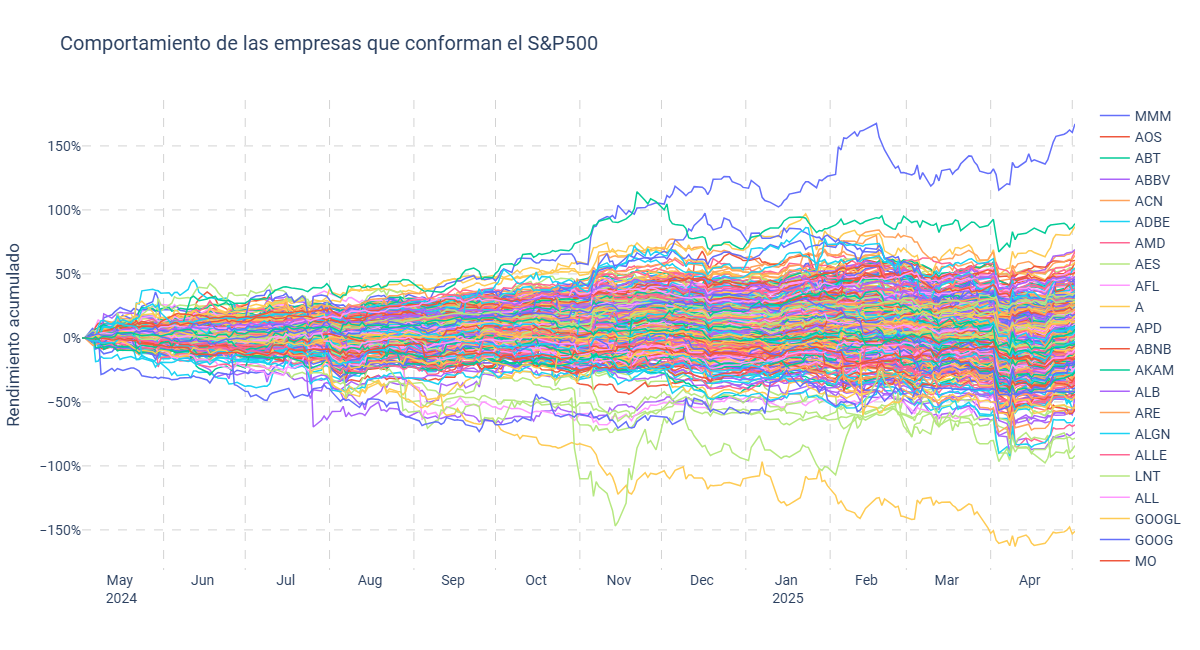

<br>

Vemos que las líneas de la gráfica no se alcanzan a distinguir. En este primer ejemplo no podemos realizar un análisis adecuado, por lo que vamos a filtrar aquellas empresas que cumplen algunos criterios específicos.

<br>

Vamos a filtrar a las empresas que hayan tenido mejores y peores desempenos a lo largo del tiempo de análisis usando una combinación de los métodos [.loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html#) e [.iloc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html):


In [ ]:
#con .iloc podemos realizar operaciones lógicas que filtra los tickers que cumplen con nuestros criterios
#de esta forma, al escribir:
rendimientos_acc.iloc[-1]< -0.50      #obtenemos una tabla con resultados booleanos

In [ ]:
#contamos cuantos tickers cumplen con la condicion:
(rendimientos_acc.iloc[-1]< -0.50).sum()

In [ ]:
#otro criterio que vamos a considerar es:
rendimientos_acc.iloc[-1]> 0.60

In [ ]:
#contamos cuantos tickers cumplen con la condicion:
(rendimientos_acc.iloc[-1]> 0.60).sum()

In [ ]:
#usamos .loc para filtrar la tabla
#.loc reconoce los valores booleanos y procesa aquellos tickers que cumplen los criterios:
lista_tickers_filtrados= rendimientos_acc.loc[:, (rendimientos_acc.iloc[-1]< -0.50) | (rendimientos_acc.iloc[-1] > 0.60)]
lista_tickers_filtrados

<br>

Ahora que tenemos la lista de empresas filtradas, procedemos a generar la grafica correspondiente:

In [ ]:
#establecemos la figura
fig = go.Figure()

#graficamos los valores
for simbolo in lista_tickers_filtrados.columns:      #itineramos por cada elemento en la lista
    fig.add_trace(go.Scatter(x= rendimientos_acc.index, y= rendimientos_acc[simbolo],
    mode= 'lines', line= dict(width= 1.5, dash= "solid"), opacity= 0.99, name= simbolo))

#diseño de la grafica
fig.update_layout(
    font=dict(size=14, family="Roboto"),      #opciones: Arial, Courier New, Verdana, Helvetica, Georgia
    title= 'Empresas con los mejores y peores desempeños dentro del S&P500',
    yaxis_title='Rendimiento acumulado',
    plot_bgcolor='white',
    paper_bgcolor= 'white',
    width=1200,  #ancho fig
    height=650,  #alto fig

    xaxis=dict(
        gridcolor= 'lightgrey',
        gridwidth=1,
        griddash= 'dash'),

    yaxis=dict(
        gridcolor= 'lightgrey',
        gridwidth=1,
        griddash= 'dash',
        zeroline=True,          #línea sobre eje X, donde y(0)=0
        zerolinecolor= 'black',
        zerolinewidth=2,
        showline=False,          #línea del eje y, costado izquierdo
        linewidth=2,
        linecolor= 'black',
        tickformat= '.0%'))

fig.update_xaxes(
    dtick="M1",                 #intervalo de las etiquetas del eje x
    tickformat="%b \n%y",       #formato de mes y año en el eje x
    ticklabelmode="period")     #posicion de las etiquetas, default: instant, otro: period

# Mostrar el gráfico
fig.show()


*Nota: Adjunto una imagen de la gráfica generada debido a que el formato de plotly no permite mostrarlo en el archivo ".ipynb". Sin embargo, no deberían  tener problema en visualizar la imagen una vez carguen y ejecuten el archivo.*

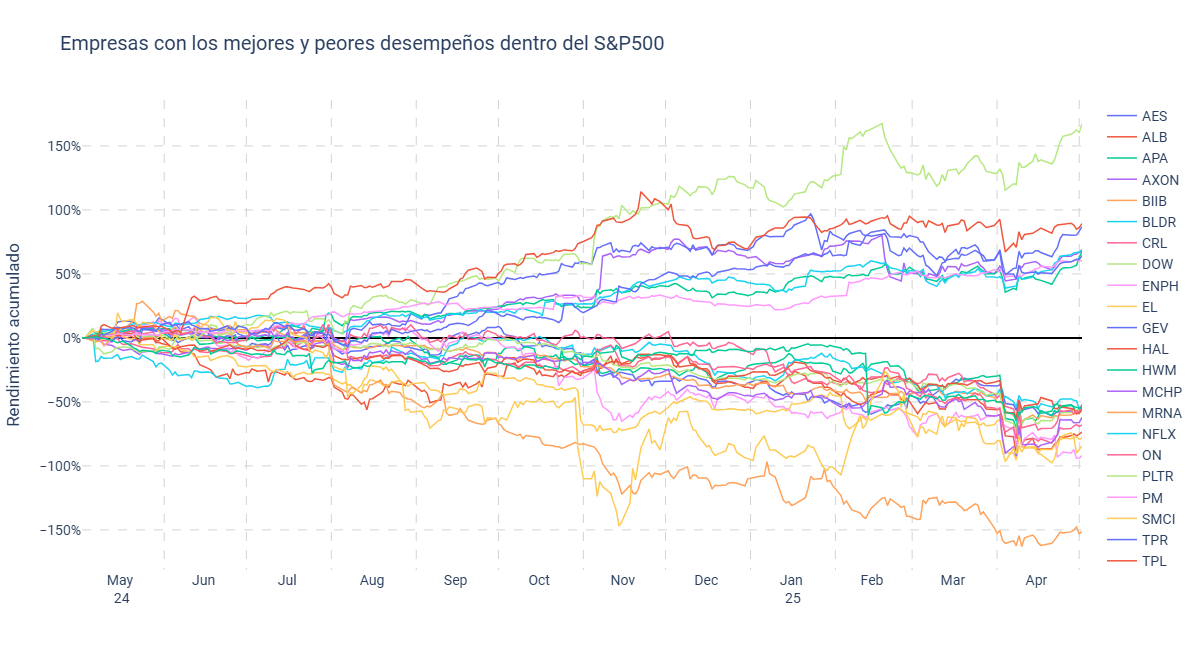